# Fetch Reach TD3 with HER

In [1]:
from pathlib import Path
import sys
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
import matplotlib.pyplot as plt
import time
import copy
import pandas as pd

import os
import imageio.v2 as imageio
import gymnasium as gym
import gymnasium_robotics

from stable_baselines3 import TD3
from stable_baselines3.her.her_replay_buffer import HerReplayBuffer
from stable_baselines3.common.monitor import Monitor
from stable_baselines3.common.callbacks import EvalCallback, CallbackList
from stable_baselines3.common.noise import NormalActionNoise


# Resolve repository src path robustly when running notebook in-place.
repo_root = Path.cwd()
while repo_root != repo_root.parent and not (repo_root / 'src').exists():
    repo_root = repo_root.parent
sys.path.insert(0, str(repo_root / 'src'))

from environments.fetch_push_env import FixedGoalWrapper, SuccessRateEvalCallback, sample_goals_from_resets
from utils import set_seed, estimate_fisher_diag, compute_embedding_drift, collect_weight_snapshot, TrajectoryReplayBuffer, evaluate_model, configure_factorised_learning_rates
from visualisations import visualise_embeddings, visualise_q_table, print_goal_embedding_similarity, plot_full_embedding_dashboard_2d_html, plot_min_steps_and_min_time
from gym_robotics_networks import DotProductTD3Policy, DotProductContinuousCritic, DotProductQNetwork, AdaptiveActionNoiseCallback, MutableNormalActionNoise


DEVICE = 'cuda' if torch.cuda.is_available() else ('mps' if torch.backends.mps.is_available() else 'cpu')
print('Using device:', DEVICE)


AdroitHandRelocateDense-v1, AdroitHandHammerDense-v1, AdroitHandDoorDense-v1 environment's reward functions were updated in v1.2.1 without an environment version update. Therefore, use gymnasium-robotics==1.2.0 for v1 reproducibility or use v2 in gymnasium-robotics>=1.4.3. See https://github.com/Farama-Foundation/Gymnasium-Robotics/pull/220 for more details


Using device: mps


## Environment Definition

In [2]:
ENV_ID = "FetchReach-v4"

SEED = 42
MAX_EPISODE_STEPS = 50
TOTAL_TIMESTEPS = 100_000

SELECTED_GOAL = np.array(
    [1.20, 0.75, 0.42],
    dtype=np.float32,
)

PROJECT_DIR = "td3_her_fetchreach"
BEST_MODEL_DIR = os.path.join(
    PROJECT_DIR,
    "best_model",
)
LOG_DIR = os.path.join(
    PROJECT_DIR,
    "logs",
)
VIDEO_DIR = os.path.join(
    PROJECT_DIR,
    "videos",
)

os.makedirs(BEST_MODEL_DIR, exist_ok=True)
os.makedirs(LOG_DIR, exist_ok=True)
os.makedirs(VIDEO_DIR, exist_ok=True)

gym.register_envs(gymnasium_robotics)

def make_goal_sampling_env(
    env_id=ENV_ID,
    render_mode=None,
    max_episode_steps=MAX_EPISODE_STEPS,
):
    base_env = gym.make(
        env_id,
        reward_type="sparse",
        max_episode_steps=max_episode_steps,
        render_mode=render_mode,
    )

    return Monitor(base_env)

def make_fixed_goal_env(
    env_id = ENV_ID,
    render_mode=None,
    goal=SELECTED_GOAL,
    max_episode_steps=MAX_EPISODE_STEPS
):
    base_env = gym.make(
        env_id,
        reward_type="sparse",
        max_episode_steps=max_episode_steps,
        render_mode=render_mode,
    )

    fixed_goal_env = FixedGoalWrapper(
        base_env,
        goal=goal,
    )

    return Monitor(fixed_goal_env)

train_env = make_fixed_goal_env(render_mode=None,)
eval_env = make_fixed_goal_env(render_mode=None,)


# ============================================================
# Environment smoke test
# ============================================================

obs, info = train_env.reset(seed=SEED)

print("Observation keys:", obs.keys())
print(
    "Observation shape:",
    obs["observation"].shape,
)
print(
    "Achieved goal:",
    obs["achieved_goal"],
)
print(
    "Desired goal:",
    obs["desired_goal"],
)
print(
    "Action space:",
    train_env.action_space,
)
print(
    "Selected goal:",
    SELECTED_GOAL,
)

assert set(obs.keys()) == {
    "observation",
    "achieved_goal",
    "desired_goal",
}

assert obs["observation"].shape == (10,)
assert obs["achieved_goal"].shape == (3,)
assert obs["desired_goal"].shape == (3,)
assert train_env.action_space.shape == (4,)

assert np.allclose(
    obs["desired_goal"],
    SELECTED_GOAL,
    atol=1e-6,
)

print("Environment smoke test passed.")


Observation keys: dict_keys(['observation', 'achieved_goal', 'desired_goal'])
Observation shape: (10,)
Achieved goal: [1.3418334  0.74910102 0.53473344]
Desired goal: [1.2  0.75 0.42]
Action space: Box(-1.0, 1.0, (4,), float32)
Selected goal: [1.2  0.75 0.42]
Environment smoke test passed.


## Training Loop

In [3]:
SEEDS = [42]

NUM_GOALS = 6

BUFFER_CAPACITY = 100_000
MAX_STEPS_PER_TASK = 100_000
LEARNING_STARTS = 5_000
BATCH_SIZE = 256

LR = 1e-3
GAMMA = 0.99
TAU = 0.005

all_run_records = []


for seed in SEEDS:
    print(
        f"\n================ SEED {seed} ================\n"
    )

    set_seed(seed)

    # GOALS = sample_goals_from_resets(
    #     make_env=make_goal_sampling_env,
    #     num_goals=NUM_GOALS,
    #     seed=seed,
    # )

    GOALS = np.array(
    [
        [1.20, 0.60, 0.41],
        [1.49, 0.60, 0.41],
        [1.20, 0.90, 0.41],
        [1.49, 0.90, 0.70],
        [1.20, 0.90, 0.70],
        [1.49, 0.60, 0.70],
    ],
    dtype=np.float32,
    )

    print(GOALS)

    sequential_model = None
    action_noise = None

    for task_idx, goal in enumerate(GOALS):
        print(
            f"\nTraining seed={seed}, "
            f"task={task_idx}, goal={goal}"
        )

        task_dir = os.path.join(
            LOG_DIR,
            f"seed_{seed}",
            f"task_{task_idx}",
        )

        os.makedirs(
            task_dir,
            exist_ok=True,
        )

        train_env = make_fixed_goal_env(
            goal=goal,
        )

        eval_env = make_fixed_goal_env(
            goal=goal,
        )

        n_actions = (
            train_env.action_space.shape[-1]
        )

        # Create one persistent noise object
        # for the whole sequential run.
        if action_noise is None:
            action_noise = (
                MutableNormalActionNoise(
                    mean=np.zeros(n_actions),
                    sigma=0.1 * np.ones(n_actions),
                )
            )

        # Use low initial exploration for new
        # tasks so the transferred policy can
        # first be assessed.
        if task_idx == 0:
            initial_sigma = 0.2
        else:
            initial_sigma = 0.1

        action_noise.set_sigma(
            initial_sigma
        )

        success_eval_callback = (
            SuccessRateEvalCallback(
                eval_env=eval_env,
                eval_freq=1000,
                n_eval_episodes=10,
                success_threshold=0.95,
                return_threshold=-12.0,
                required_checkpoints=1,
                log_path=task_dir,
                deterministic=True,
                verbose=1,
            )
        )

        adaptive_noise_callback = (
            AdaptiveActionNoiseCallback(
                action_noise=action_noise,
                success_callback=(
                    success_eval_callback
                ),
                success_threshold=0.95,
                initial_sigma=initial_sigma,
                min_sigma=0.01,
                max_sigma=0.08,
                increase_factor=1.5,
                decrease_factor=0.5,
                poor_eval_patience=2,
                verbose=1,
            )
        )

        callback = CallbackList([
            success_eval_callback,
            adaptive_noise_callback,
        ])

        if sequential_model is None:
            sequential_model = TD3(
                policy=DotProductTD3Policy,
                env=train_env,

                replay_buffer_class=(
                    HerReplayBuffer
                ),

                replay_buffer_kwargs={
                    "n_sampled_goal": 4,
                    "goal_selection_strategy": (
                        "future"
                    ),
                },

                buffer_size=BUFFER_CAPACITY,
                learning_starts=LEARNING_STARTS,
                batch_size=BATCH_SIZE,

                learning_rate=LR,
                gamma=GAMMA,
                tau=TAU,

                train_freq=(1, "step"),
                gradient_steps=1,

                policy_delay=2,
                target_policy_noise=0.2,
                target_noise_clip=0.5,

                action_noise=action_noise,

                policy_kwargs={
                    "net_arch": [
                        256,
                        256,
                        256,
                    ],
                },

                tensorboard_log=LOG_DIR,
                seed=seed,
                verbose=1,
            )

            # Configure the factorised critic
            # optimiser only once. Calling this
            # at every task would reset Adam state.
            configure_factorised_learning_rates(
                model=sequential_model,
                actor_lr=1e-3,
                phi_lr=1e-3,
                goal_lr=1e-3,
            )

        else:
            sequential_model.set_env(
                train_env,
                force_reset=True,
            )

            # Ensure the reused TD3 model uses
            # the persistent mutable noise object.
            sequential_model.action_noise = (
                action_noise
            )

        sequential_model.learn(
            total_timesteps=(
                MAX_STEPS_PER_TASK
            ),
            callback=callback,
            reset_num_timesteps=True,
            tb_log_name=(
                f"seed_{seed}_task_{task_idx}"
            ),
            progress_bar=False,
        )

        actual_steps_used = int(
            sequential_model.num_timesteps
        )

        steps_to_target = (
            success_eval_callback.steps_to_target
        )

        target_reached = (
            steps_to_target is not None
        )

        # Save model checkpoint.
        model_path = os.path.join(
            task_dir,
            "model",
        )

        sequential_model.save(
            model_path
        )

        # Save replay buffer.
        replay_buffer_path = os.path.join(
            task_dir,
            "replay_buffer",
        )

        sequential_model.save_replay_buffer(
            replay_buffer_path
        )

        # Save task metadata.
        metadata_path = os.path.join(
            task_dir,
            "metadata.npz",
        )

        np.savez(
            metadata_path,
            seed=seed,
            task_idx=task_idx,
            goal=np.asarray(
                goal,
                dtype=np.float32,
            ),
            max_steps=(
                MAX_STEPS_PER_TASK
            ),
            learning_starts=(
                LEARNING_STARTS
            ),
            batch_size=BATCH_SIZE,
            learning_rate=LR,
            gamma=GAMMA,
            tau=TAU,
            initial_action_sigma=(
                initial_sigma
            ),
            final_action_sigma=(
                action_noise.get_sigma()
            ),
        )

        # Store lightweight in-memory record.
        task_record = {
            "seed": seed,
            "task_idx": task_idx,
            "goal": np.asarray(
                goal,
                dtype=np.float32,
            ),

            "task_dir": task_dir,
            "model_path": model_path,
            "replay_buffer_path": (
                replay_buffer_path
            ),
            "metadata_path": metadata_path,

            "steps_to_target": (
                steps_to_target
            ),
            "steps_used": (
                actual_steps_used
            ),
            "target_reached": (
                target_reached
            ),

            "success_rates": np.asarray(
                success_eval_callback.success_rates
            ),
            "eval_steps": np.asarray(
                success_eval_callback.eval_steps
            ),

            "initial_action_sigma": (
                initial_sigma
            ),
            "final_action_sigma": (
                action_noise.get_sigma()
            ),
        }

        all_run_records.append(
            task_record
        )

        print(
            f"Final action-noise sigma: "
            f"{action_noise.get_sigma():.4f}"
        )

        print(
            f"Saved task checkpoint to:\n"
            f"{task_dir}"
        )

        actor_path = os.path.join(
            task_dir,
            "actor_final.pt",
        )

        torch.save(
            sequential_model.policy.actor.state_dict(),
            actor_path,
        )

        result_path = os.path.join(
            task_dir,
            "task_result.npz",
        )

        np.savez(
            result_path,
            seed=seed,
            task_idx=task_idx,
            goal=np.asarray(
                goal,
                dtype=np.float32,
            ),
            steps_to_target=(
                np.nan
                if steps_to_target is None
                else steps_to_target
            ),
            steps_used=actual_steps_used,
            target_reached=target_reached,
            success_rates=np.asarray(
                success_eval_callback.success_rates,
                dtype=np.float32,
            ),
            eval_steps=np.asarray(
                success_eval_callback.eval_steps,
                dtype=np.int64,
            ),
            initial_action_sigma=(
                initial_sigma
            ),
            final_action_sigma=(
                action_noise.get_sigma()
            ),
        )

        eval_env.close()
        train_env.close()


================ SEED 42 ================

[[1.2  0.6  0.41]
 [1.49 0.6  0.41]
 [1.2  0.9  0.41]
 [1.49 0.9  0.7 ]
 [1.2  0.9  0.7 ]
 [1.49 0.6  0.7 ]]

Training seed=42, task=0, goal=[1.2  0.6  0.41]
Using cpu device
Wrapping the env in a DummyVecEnv.
Configured factorised learning rates:
critic group 0: lr=0.001, n_params=8
critic group 1: lr=0.001, n_params=8
actor group 0: lr=0.001
Logging to td3_her_fetchreach/logs/seed_42_task_0_18
[Adaptive noise] Initial sigma: 0.2000
---------------------------------
| rollout/           |          |
|    ep_len_mean     | 50       |
|    ep_rew_mean     | -50      |
|    success_rate    | 0        |
| time/              |          |
|    episodes        | 4        |
|    fps             | 2275     |
|    time_elapsed    | 0        |
|    total_timesteps | 200      |
---------------------------------
---------------------------------
| rollout/           |          |
|    ep_len_mean     | 50       |
|    ep_rew_mean     | -50      |
|    suc

/Users/juntan/Documents/MSc_Applied_Machine_Learning/Repos/Dissertation/MSc_Dissertation/.venv/lib/python3.12/site-packages/gymnasium/utils/passive_env_checker.py:133: UserWarning: WARN: The obs returned by the `step()` method was expecting numpy array dtype to be float64, actual type: float32
  logger.warn(


---------------------------------
| rollout/           |          |
|    ep_len_mean     | 50       |
|    ep_rew_mean     | -50      |
|    success_rate    | 0        |
| time/              |          |
|    episodes        | 12       |
|    fps             | 2194     |
|    time_elapsed    | 0        |
|    total_timesteps | 600      |
---------------------------------
---------------------------------
| rollout/           |          |
|    ep_len_mean     | 50       |
|    ep_rew_mean     | -50      |
|    success_rate    | 0        |
| time/              |          |
|    episodes        | 16       |
|    fps             | 2211     |
|    time_elapsed    | 0        |
|    total_timesteps | 800      |
---------------------------------
Step 1,000 | Success: 0.000 | Qualified: 0.000 | Return: -50.000 | Return threshold: -12.000 | Required successes: 10/10 | Consecutive: 0/1
[Adaptive noise] evaluation success=0.000, sigma=0.2000 -> 0.2000, unchanged
---------------------------------
|

## Plots

In [4]:
summary_rows = []

for record in all_run_records:
    summary_rows.append({
        "seed": record["seed"],
        "task_idx": record["task_idx"],
        "task_number": record["task_idx"] + 1,
        "goal": record["goal"],
        "steps_to_target": record[
            "steps_to_target"
        ],
        "steps_used": record[
            "steps_used"
        ],
        "target_reached": record[
            "target_reached"
        ],
    })

summary_df = pd.DataFrame(
    summary_rows
)

summary_path = os.path.join(
    LOG_DIR,
    "task_learning_summary.csv",
)

summary_df.to_csv(
    summary_path,
    index=False,
)

print(
    "Saved summary to:",
    summary_path,
)

Saved summary to: td3_her_fetchreach/logs/task_learning_summary.csv


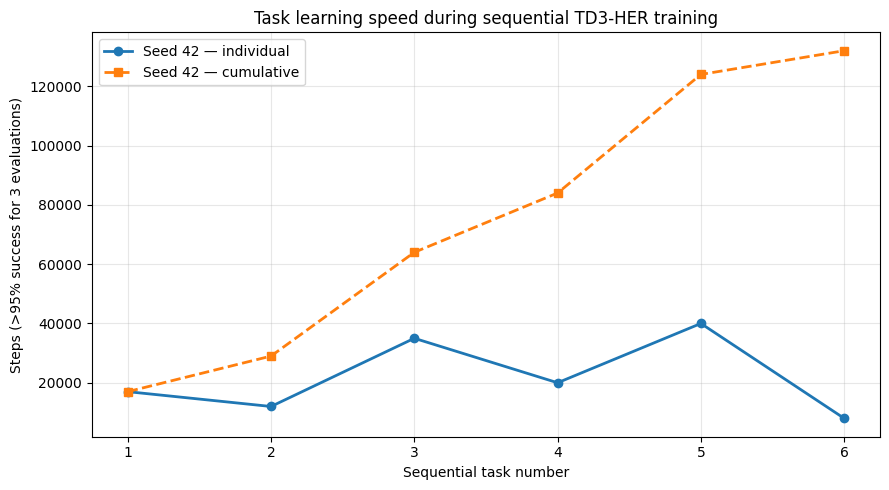

In [9]:
import matplotlib.pyplot as plt


plt.figure(figsize=(9, 5))


for seed in SEEDS:
    seed_df = (
        summary_df[
            summary_df["seed"] == seed
        ]
        .sort_values("task_idx")
        .copy()
    )

    # Plot steps required for each individual task
    plt.plot(
        seed_df["task_number"],
        seed_df["steps_to_target"],
        marker="o",
        linewidth=2,
        label=f"Seed {seed} — individual",
    )

    # Calculate and plot cumulative steps
    seed_df["cumulative_steps"] = (
        seed_df["steps_to_target"].cumsum()
    )

    plt.plot(
        seed_df["task_number"],
        seed_df["cumulative_steps"],
        marker="s",
        linestyle="--",
        linewidth=2,
        label=f"Seed {seed} — cumulative",
    )


plt.xlabel("Sequential task number")
plt.ylabel(
    "Steps "
    "(>95% success for 3 evaluations)"
)

plt.title(
    "Task learning speed during sequential TD3-HER training"
)

plt.xticks(range(1, NUM_GOALS + 1))
plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

td3_her_fetchreach/logs/seed_42/task_0/success_evaluations.npz

Loaded: td3_her_fetchreach/logs/seed_42/task_0/success_evaluations.npz
Available keys: ['timesteps', 'success_rates', 'returns', 'qualified_success_rates']
td3_her_fetchreach/logs/seed_42/task_1/success_evaluations.npz

Loaded: td3_her_fetchreach/logs/seed_42/task_1/success_evaluations.npz
Available keys: ['timesteps', 'success_rates', 'returns', 'qualified_success_rates']
td3_her_fetchreach/logs/seed_42/task_2/success_evaluations.npz

Loaded: td3_her_fetchreach/logs/seed_42/task_2/success_evaluations.npz
Available keys: ['timesteps', 'success_rates', 'returns', 'qualified_success_rates']
td3_her_fetchreach/logs/seed_42/task_3/success_evaluations.npz

Loaded: td3_her_fetchreach/logs/seed_42/task_3/success_evaluations.npz
Available keys: ['timesteps', 'success_rates', 'returns', 'qualified_success_rates']
td3_her_fetchreach/logs/seed_42/task_4/success_evaluations.npz

Loaded: td3_her_fetchreach/logs/seed_42/task_4/success_e

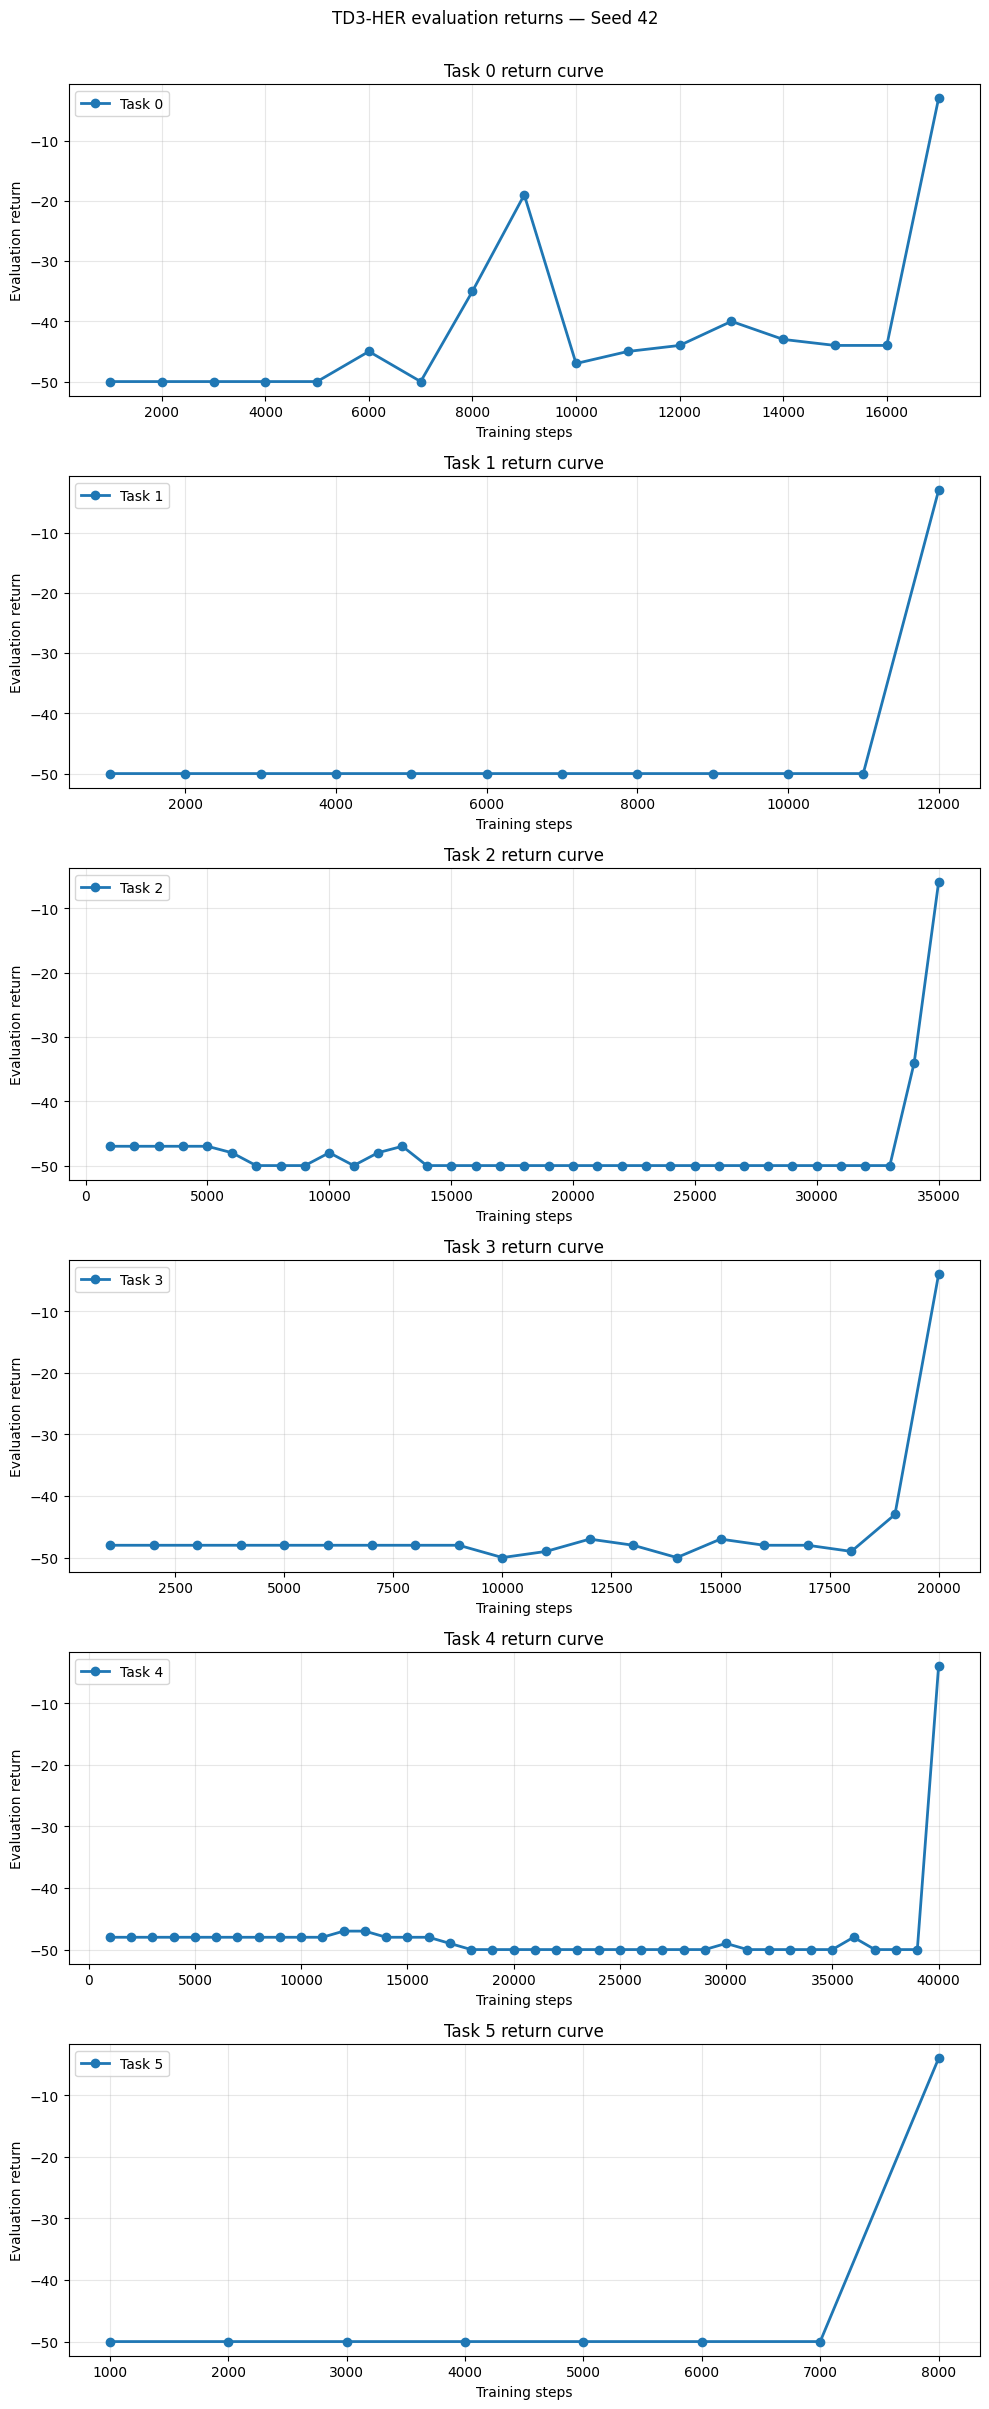

In [6]:
def load_evaluation_npz(path):
    data = np.load(path)

    print(
        f"\nLoaded: {path}"
    )
    print(
        "Available keys:",
        data.files,
    )

    steps = data["timesteps"]

    if "results" in data.files:
        returns = data["results"]

    elif "returns" in data.files:
        returns = data["returns"]

    else:
        raise KeyError(
            "Could not find 'results' or 'returns' "
            f"in {path}"
        )

    returns = np.asarray(returns)

    # Standard EvalCallback format:
    # [n_evaluations, n_episodes]
    if returns.ndim == 2:
        mean_returns = returns.mean(axis=1)
        std_returns = returns.std(axis=1)

    # Custom callback may already store means:
    # [n_evaluations]
    elif returns.ndim == 1:
        mean_returns = returns
        std_returns = np.zeros_like(
            mean_returns
        )

    else:
        raise ValueError(
            f"Unexpected return shape: {returns.shape}"
        )

    return {
        "steps": steps,
        "returns": returns,
        "mean_returns": mean_returns,
        "std_returns": std_returns,
    }

SEED_TO_PLOT = 42

fig, axes = plt.subplots(
    nrows=NUM_GOALS,
    ncols=1,
    figsize=(10, 4 * NUM_GOALS),
    squeeze=False,
)

axes = axes.flatten()

for task_idx in range(NUM_GOALS):
    task_eval_path = os.path.join(
        LOG_DIR,
        f"seed_{SEED_TO_PLOT}",
        f"task_{task_idx}",
        "success_evaluations.npz",
    )

    print(task_eval_path)
    ax = axes[task_idx]

    if not os.path.exists(task_eval_path):
        ax.set_title(
            f"Task {task_idx}: evaluation file missing"
        )
        ax.grid(alpha=0.3)
        continue

    task_data = load_evaluation_npz(
        task_eval_path
    )

    steps = task_data["steps"]
    mean_returns = task_data["mean_returns"]
    std_returns = task_data["std_returns"]

    ax.plot(
        steps,
        mean_returns,
        marker="o",
        linewidth=2,
        label=f"Task {task_idx}",
    )

    ax.fill_between(
        steps,
        mean_returns - std_returns,
        mean_returns + std_returns,
        alpha=0.2,
    )

    ax.set_title(
        f"Task {task_idx} return curve"
    )

    ax.set_xlabel("Training steps")
    ax.set_ylabel("Evaluation return")
    ax.grid(alpha=0.3)
    ax.legend()

plt.suptitle(
    f"TD3-HER evaluation returns — Seed {SEED_TO_PLOT}",
    y=1.002,
)

plt.tight_layout()
plt.show()

In [7]:
import os
import glob
import numpy as np
import imageio.v2 as imageio
import gymnasium as gym
import torch as th

from stable_baselines3 import TD3
from stable_baselines3.common.vec_env import DummyVecEnv


# ============================================================
# Find actor checkpoint
# ============================================================

def find_actor_checkpoint(task_dir):
    candidates = [
        os.path.join(task_dir, "actor_best.pt"),
        os.path.join(task_dir, "actor_final.pt"),
        os.path.join(task_dir, "actor.pt"),
    ]

    for path in candidates:
        if os.path.exists(path):
            return path

    pt_files = glob.glob(
        os.path.join(task_dir, "*.pt")
    )

    if len(pt_files) == 1:
        return pt_files[0]

    if len(pt_files) > 1:
        best_files = [
            path
            for path in pt_files
            if "best" in os.path.basename(path).lower()
        ]

        if best_files:
            return best_files[0]

        return sorted(pt_files)[-1]

    raise FileNotFoundError(
        f"No actor checkpoint found in {task_dir}"
    )


# ============================================================
# Build render environment
# ============================================================

def make_task_render_env(goal):
    base_env = gym.make(
        "FetchReach-v4",
        reward_type="sparse",
        max_episode_steps=50,
        render_mode="rgb_array",
    )

    fixed_goal_env = FixedGoalWrapper(
        base_env,
        goal=np.asarray(
            goal,
            dtype=np.float32,
        ),
    )

    return fixed_goal_env


# ============================================================
# GIF helper using actor-only checkpoint
# ============================================================

def render_td3_actor_gif(
    task_index,
    goals,
    seed=42,
    experiment_dir="td3_her_fetchreach",
    output_dir=None,
    episode_seed=123,
    fps=20,
):
    if output_dir is None:
        output_dir = os.path.join(
            experiment_dir,
            "task_gifs",
        )

    os.makedirs(
        output_dir,
        exist_ok=True,
    )

    goals = np.asarray(
        goals,
        dtype=np.float32,
    )

    if task_index < 0 or task_index >= len(goals):
        raise IndexError(
            f"Invalid task index {task_index}. "
            f"Available range: "
            f"0 to {len(goals) - 1}"
        )

    goal = goals[task_index]

    task_dir = os.path.join(
        experiment_dir,
        "logs",
        f"seed_{seed}",
        f"task_{task_index}",
    )

    actor_checkpoint = find_actor_checkpoint(
        task_dir
    )

    print(
        f"Loading actor for task {task_index}:"
    )
    print(actor_checkpoint)
    print("Goal:", goal)

    # Create the same architecture used during
    # training. This must match the saved actor.
    base_env = gym.make(
        "FetchReach-v4",
        reward_type="sparse",
        max_episode_steps=50,
        render_mode="rgb_array",
    )

    fixed_goal_env = FixedGoalWrapper(
        base_env,
        goal=goal,
    )

    vec_env = DummyVecEnv(
        [
            lambda: fixed_goal_env
        ]
    )

    # Create a fresh TD3 model with the
    # same custom policy architecture.
    model = TD3(
        policy=DotProductTD3Policy,
        env=vec_env,

        replay_buffer_class=HerReplayBuffer,
        replay_buffer_kwargs={
            "n_sampled_goal": 4,
            "goal_selection_strategy": "future",
        },

        buffer_size=1_000_000,
        learning_starts=1_000,
        batch_size=256,

        learning_rate=3e-4,
        gamma=0.95,
        tau=0.005,

        train_freq=(1, "step"),
        gradient_steps=1,

        policy_delay=2,
        target_policy_noise=0.2,
        target_noise_clip=0.5,

        action_noise=None,

        policy_kwargs={
            "net_arch": [256, 256, 256],
            "share_features_extractor": False,
        },

        device="cpu",
        seed=seed,
        verbose=0,
    )

    actor_state = th.load(
        actor_checkpoint,
        map_location="cpu",
    )

    model.policy.actor.load_state_dict(
        actor_state,
        strict=True,
    )

    model.policy.actor.eval()

    obs = vec_env.reset()

    frames = []

    frame = vec_env.render()

    if frame is not None:
        frames.append(
            np.asarray(frame)
        )

    done = False
    episode_return = 0.0
    episode_length = 0
    minimum_distance = float("inf")
    success = False

    while not done:
        action, _ = model.predict(
            obs,
            deterministic=True,
        )

        obs, rewards, dones, infos = (
            vec_env.step(action)
        )

        done = bool(dones[0])

        episode_return += float(
            rewards[0]
        )

        episode_length += 1

        info = infos[0]

        if "goal_dist" in info:
            distance = float(
                info["goal_dist"]
            )
        else:
            achieved_goal = np.asarray(
                info.get(
                    "achieved_goal",
                    [np.nan, np.nan, np.nan],
                ),
                dtype=np.float32,
            )

            distance = float(
                np.linalg.norm(
                    achieved_goal - goal
                )
            )

        minimum_distance = min(
            minimum_distance,
            distance,
        )

        if "is_success" in info:
            success = bool(
                info["is_success"]
            )
        elif distance <= 0.05:
            success = True

        frame = vec_env.render()

        if frame is not None:
            frames.append(
                np.asarray(frame)
            )

    vec_env.close()

    if not frames:
        raise RuntimeError(
            f"No frames generated for task "
            f"{task_index}."
        )

    gif_path = os.path.join(
        output_dir,
        f"task_{task_index}_actor_policy.gif",
    )

    imageio.mimsave(
        gif_path,
        frames,
        duration=1.0 / fps,
        loop=0,
    )

    result = {
        "task_index": task_index,
        "goal": goal,
        "actor_checkpoint": actor_checkpoint,
        "gif_path": gif_path,
        "return": episode_return,
        "episode_length": episode_length,
        "minimum_distance": minimum_distance,
        "success": success,
        "frames": len(frames),
    }

    print("\nTask result:")

    for key, value in result.items():
        print(f"{key}: {value}")

    return result

Loading actor for task 0:
td3_her_fetchreach/logs/seed_42/task_0/actor_final.pt
Goal: [1.2  0.6  0.41]


/Users/juntan/Documents/MSc_Applied_Machine_Learning/Repos/Dissertation/MSc_Dissertation/.venv/lib/python3.12/site-packages/gymnasium/utils/passive_env_checker.py:133: UserWarning: WARN: The obs returned by the `step()` method was expecting numpy array dtype to be float64, actual type: float32
  logger.warn(



Task result:
task_index: 0
goal: [1.2  0.6  0.41]
actor_checkpoint: td3_her_fetchreach/logs/seed_42/task_0/actor_final.pt
gif_path: td3_her_fetchreach/task_gifs/task_0_actor_policy.gif
return: -3.0
episode_length: 50
minimum_distance: 0.009573230519890785
success: True
frames: 51
Loading actor for task 1:
td3_her_fetchreach/logs/seed_42/task_1/actor_final.pt
Goal: [1.49 0.6  0.41]

Task result:
task_index: 1
goal: [1.49 0.6  0.41]
actor_checkpoint: td3_her_fetchreach/logs/seed_42/task_1/actor_final.pt
gif_path: td3_her_fetchreach/task_gifs/task_1_actor_policy.gif
return: -3.0
episode_length: 50
minimum_distance: 0.016123048961162567
success: True
frames: 51
Loading actor for task 2:
td3_her_fetchreach/logs/seed_42/task_2/actor_final.pt
Goal: [1.2  0.9  0.41]

Task result:
task_index: 2
goal: [1.2  0.9  0.41]
actor_checkpoint: td3_her_fetchreach/logs/seed_42/task_2/actor_final.pt
gif_path: td3_her_fetchreach/task_gifs/task_2_actor_policy.gif
return: -6.0
episode_length: 50
minimum_dist

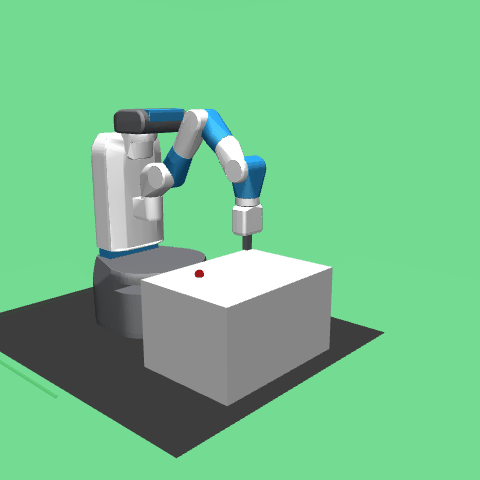

Task 1 | success=True | return=-3.000


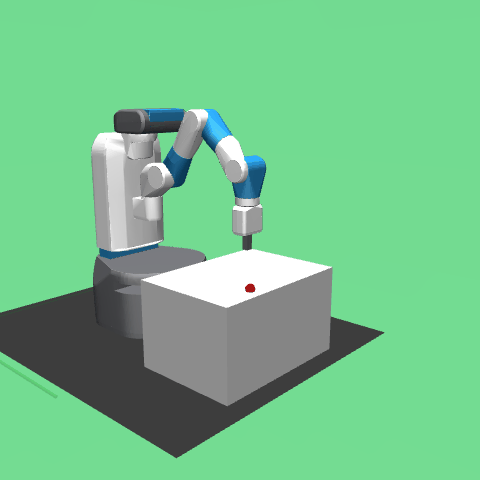

Task 2 | success=True | return=-6.000


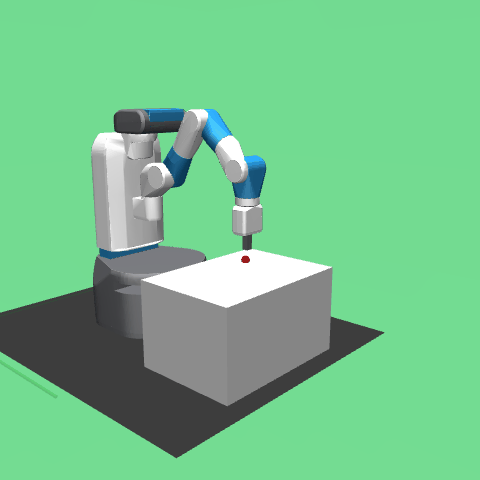

Task 3 | success=True | return=-4.000


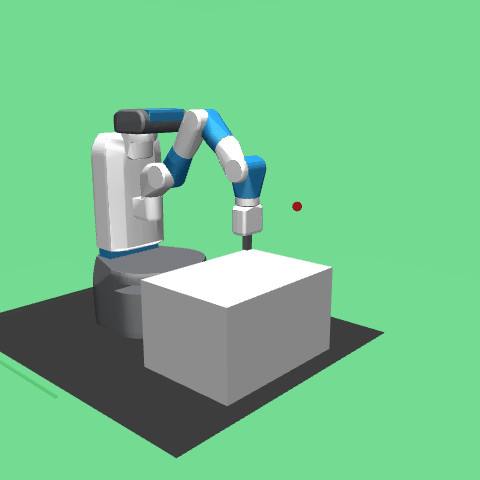

Task 4 | success=True | return=-4.000


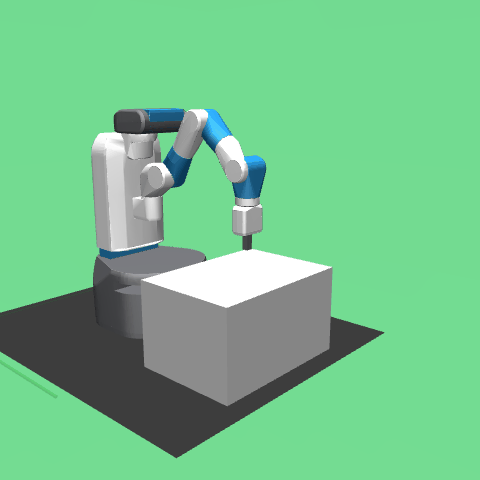

Task 5 | success=True | return=-4.000


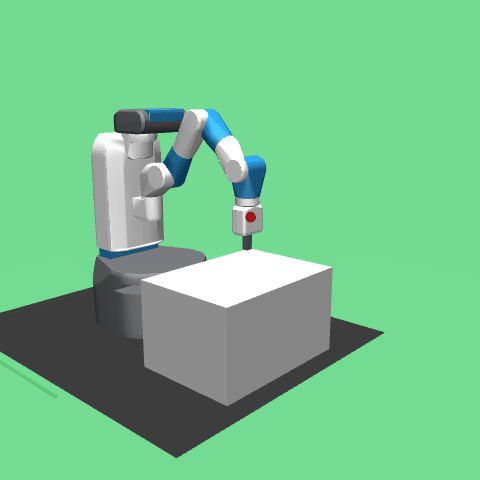

In [8]:
all_task_results = []

for task_index in range(len(GOALS)):
    result = render_td3_actor_gif(
        task_index=task_index,
        goals=GOALS,
        seed=42,
    )

    all_task_results.append(result)


from IPython.display import Image, display

for result in all_task_results:
    print(
        f"Task {result['task_index']} | "
        f"success={result['success']} | "
        f"return={result['return']:.3f}"
    )

    display(
        Image(
            filename=result["gif_path"]
        )
    )

Evaluating final actor on task 0, goal=[1.2  0.6  0.41]


/Users/juntan/Documents/MSc_Applied_Machine_Learning/Repos/Dissertation/MSc_Dissertation/.venv/lib/python3.12/site-packages/gymnasium/utils/passive_env_checker.py:133: UserWarning: WARN: The obs returned by the `step()` method was expecting numpy array dtype to be float64, actual type: float32
  logger.warn(


Evaluating final actor on task 1, goal=[1.49 0.6  0.41]
Evaluating final actor on task 2, goal=[1.2  0.9  0.41]
Evaluating final actor on task 3, goal=[1.49 0.9  0.7 ]
Evaluating final actor on task 4, goal=[1.2 0.9 0.7]
Evaluating final actor on task 5, goal=[1.49 0.6  0.7 ]


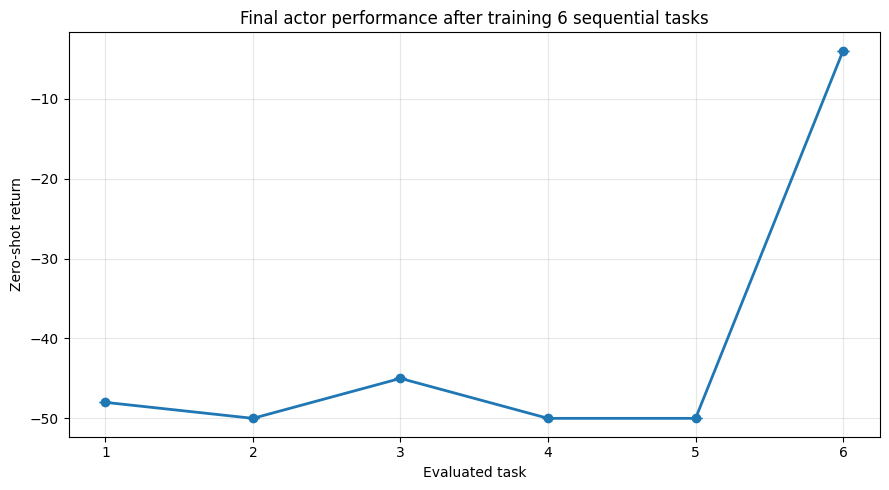

,seed,trained_tasks,evaluated_task,mean_return,std_return
0,42,6,0,-48.0,0.0
1,42,6,1,-50.0,0.0
2,42,6,2,-45.0,0.0
3,42,6,3,-50.0,0.0
4,42,6,4,-50.0,0.0
5,42,6,5,-4.0,0.0


In [13]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch


# ------------------------------------------------------------
# Configuration
# ------------------------------------------------------------

N = len(GOALS)
NUM_EVAL_EPISODES = 10
MAX_EPISODE_STEPS = 500
DEVICE = "cpu"

final_task_idx = N - 1

final_task_dir = os.path.join(
    LOG_DIR,
    f"seed_{seed}",
    f"task_{final_task_idx}",
)


# ------------------------------------------------------------
# Reconstruct an evaluation model
#
# This must use the same policy class and policy_kwargs
# as the original training model.
# ------------------------------------------------------------

eval_env = make_fixed_goal_env(
    goal=GOALS[-1],
)

n_actions = eval_env.action_space.shape[-1]


evaluation_model = TD3(
    policy=DotProductTD3Policy,
    env=eval_env,
    replay_buffer_class=HerReplayBuffer,
    replay_buffer_kwargs={
        "n_sampled_goal": 4,
        "goal_selection_strategy": "future",
    },
    buffer_size=BUFFER_CAPACITY,
    learning_starts=LEARNING_STARTS,
    batch_size=BATCH_SIZE,
    learning_rate=LR,
    gamma=GAMMA,
    tau=TAU,
    train_freq=(1, "step"),
    gradient_steps=1,
    policy_delay=2,
    target_policy_noise=0.2,
    target_noise_clip=0.5,
    action_noise=None,
    policy_kwargs={
        "net_arch": [
            256,
            256,
            256,
        ],
    },
    seed=seed,
    device=DEVICE,
    verbose=0,
)


# ------------------------------------------------------------
# Load the final actor weights directly
# ------------------------------------------------------------

actor_path = os.path.join(
    final_task_dir,
    "actor_final.pt",
)

actor_state_dict = torch.load(
    actor_path,
    map_location=DEVICE,
)

evaluation_model.policy.actor.load_state_dict(
    actor_state_dict,
    strict=True,
)

evaluation_model.policy.actor.to(DEVICE)
evaluation_model.policy.actor.eval()


# ------------------------------------------------------------
# Evaluate the final actor zero-shot on every goal
# ------------------------------------------------------------

final_eval_rows = []


for evaluated_task_idx, goal in enumerate(
    GOALS,
    start=0,
):
    print(
        f"Evaluating final actor on task "
        f"{evaluated_task_idx}, goal={goal}"
    )

    task_eval_env = make_fixed_goal_env(
        goal=goal,
    )

    episode_returns = []

    for episode_idx in range(
        NUM_EVAL_EPISODES
    ):
        reset_output = task_eval_env.reset()

        if isinstance(reset_output, tuple):
            obs, info = reset_output
        else:
            obs = reset_output
            info = {}

        episode_return = 0.0

        for _ in range(MAX_EPISODE_STEPS):
            # This uses the final actor directly.
            # No exploration noise is added.
            action, _ = evaluation_model.predict(
                obs,
                deterministic=True,
            )

            step_output = task_eval_env.step(action)

            if len(step_output) == 5:
                next_obs, reward, terminated, truncated, info = (
                    step_output
                )
                done = terminated or truncated
            else:
                next_obs, reward, done, info = step_output

            episode_return += float(reward)
            obs = next_obs

            if done:
                break

        episode_returns.append(episode_return)

    task_eval_env.close()

    final_eval_rows.append(
        {
            "seed": seed,
            "trained_tasks": N,
            "evaluated_task": evaluated_task_idx,
            "goal": np.asarray(
                goal,
                dtype=np.float32,
            ),
            "mean_return": np.mean(
                episode_returns
            ),
            "std_return": np.std(
                episode_returns
            ),
            "returns": episode_returns,
        }
    )


eval_env.close()


final_evaluation_df = pd.DataFrame(
    final_eval_rows
)


# ------------------------------------------------------------
# Plot final zero-shot return against task number
# ------------------------------------------------------------

plt.figure(figsize=(9, 5))

plt.errorbar(
    final_evaluation_df["evaluated_task"] + 1,
    final_evaluation_df["mean_return"],
    yerr=final_evaluation_df["std_return"],
    marker="o",
    capsize=4,
    linewidth=2,
)

plt.xlabel("Evaluated task")
plt.ylabel("Zero-shot return")

plt.title(
    f"Final actor performance after training "
    f"{N} sequential tasks"
)

plt.xticks(
    range(1, N + 1)
)

plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()


display(
    final_evaluation_df[
        [
            "seed",
            "trained_tasks",
            "evaluated_task",
            "mean_return",
            "std_return",
        ]
    ]
)